# Block 4: Hugging Face Ecosystem — Erklärungs-Notebook
## Live-Demo für die LEHRE-Phase (09:30–10:00)

Dieses Notebook begleitet den ersten Lehrteil zu Hugging Face.  
Es enthält **alle Code-Beispiele bereits ausgeführt** — Sie können es zum Mitlesen und Nachvollziehen verwenden.

**Inhalte:**
1. Hugging Face Hub — Modelle finden und verstehen
2. Transformers Library — AutoModel, AutoTokenizer, Pipeline
3. **Tokenisierung im Detail**
   - BPE-Konzept
   - `encode` / `decode` / `tokenize` und Hilfsmethoden
   - Spezial-Tokens (EOS, BOS, PAD, UNK)
   - Padding, Truncation, Batch-Encoding, attention_mask
   - Token-Grenzen für Interpretability-Analyse
4. Manueller Forward Pass — Logits, Hidden States, Attention
5. Open-Weight vs. API vs. Lokal — Konzeptioneller Vergleich

**Voraussetzungen:** Python 3.10+, `transformers`, `torch`, `matplotlib`

## 0. Setup

Wir laden alle benötigten Bibliotheken. Falls etwas fehlt:
```bash
uv add transformers torch matplotlib
```

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import matplotlib.pyplot as plt
import numpy as np

# Device wählen: MPS (Apple Silicon), CUDA (NVIDIA), oder CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")

PyTorch Version: 2.12.0+cpu
Device: cpu


---
## 1. Der Hugging Face Hub

Der **Hugging Face Hub** (huggingface.co) ist das *GitHub für Machine-Learning-Modelle*.  
Über **1 Million Modelle**, **200.000+ Datasets** und **500.000+ Spaces** sind verfügbar (Stand 2026).

**Wichtige Komponenten pro Modell-Repository:**
- `config.json` — Architektur-Definition (n_layers, n_heads, d_model, vocab_size)
- `pytorch_model.bin` / `model.safetensors` — Gewichte
- `tokenizer.json` + `vocab.json` — Tokenizer-Konfiguration
- `README.md` — **Model Card** (Mitchell et al., 2019): Intended Use, Training Data, Limitations

**Beispiel:** Öffnen Sie https://huggingface.co/gpt2 und sehen Sie sich die Model Card an.

In [22]:
# Wir können die Konfiguration eines Modells direkt vom Hub abrufen,
# ohne das Modell selbst herunterzuladen.
from transformers import AutoConfig

config = AutoConfig.from_pretrained('gpt2')
print(f"Modell-Typ:           {config.model_type}")
print(f"Vokabulargröße:       {config.vocab_size:,}")
print(f"Hidden-Dimension:     {config.n_embd}")
print(f"Anzahl Layer:         {config.n_layer}")
print(f"Anzahl Attention-Heads: {config.n_head}")
print(f"Max. Kontextlänge:    {config.n_positions:,}")

Modell-Typ:           gpt2
Vokabulargröße:       50,257
Hidden-Dimension:     768
Anzahl Layer:         12
Anzahl Attention-Heads: 12
Max. Kontextlänge:    1,024


In [23]:
config

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.9.0",
  "use_cache": true,
  "vocab_size": 50257
}

**Was sehen wir hier?**  
GPT-2 (124M-Variante) hat:
- **50.257 Tokens** im Vokabular (Byte-Level BPE)
- **768-dimensionale** versteckte Repräsentationen
- **12 Transformer-Schichten**
- **12 Attention-Heads pro Schicht**
- **1.024 Tokens** maximale Kontextlänge

→ Insgesamt ca. **124 Millionen Parameter** — klein genug, um auf jedem Laptop zu laufen.

---
## 2. Die Transformers Library

### 2.1 Pipeline API (High-Level)

Die `pipeline()`-Funktion ist die **schnellste Art**, ein Modell zu nutzen.  
Sie verbirgt Tokenisierung, Inferenz und Dekodierung hinter einer einzigen Zeile.

In [24]:
generator = pipeline('text-generation', model='gpt2', device=device)
result = generator("The capital of France is", max_new_tokens=10, do_sample=False)
print(result[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The capital of France is the capital of the French Republic, and the capital


**Praktisch**, aber: Wir sehen keine Logits, keine Hidden States, keine Attention.  
Für **Mechanistic Interpretability** brauchen wir Zugriff auf das Modell-Innere — also die Low-Level-API.

### 2.2 Auto-Klassen (Low-Level)

`AutoModel` und `AutoTokenizer` lösen den konkreten Architektur-Typ zur Laufzeit auf.  
Derselbe Code funktioniert für GPT-2, LLaMA, Mistral, … — solange das Modell auf dem Hub ist.

In [25]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')
model = AutoModelForCausalLM.from_pretrained('gpt2', attn_implementation = "eager").to(device)
model.eval()  # Inferenz-Modus (kein Dropout)

print(f"Tokenizer-Typ: {type(tokenizer).__name__}")
print(f"Modell-Typ:    {type(model).__name__}")
print(f"Parameter:     {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Tokenizer-Typ: GPT2Tokenizer
Modell-Typ:    GPT2LMHeadModel
Parameter:     124,439,808


In [26]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

wte = Word Token Embedding
Die Embedding-Tabelle, die jede Token-ID auf einen Vektor abbildet. Embedding(50257, 768) bedeutet: 50.257 Tokens im Vokabular (Standard-GPT-2-BPE-Größe), jeweils repräsentiert durch einen 768-dimensionalen Vektor.
wpe = Word Position Embedding
Die Positions-Embeddings. Embedding(1024, 768) heißt: für jede der 1024 möglichen Positionen im Kontextfenster gibt es einen gelernten 768-dim Vektor. Der wird zum Token-Embedding addiert, damit das Modell weiß, wo im Satz ein Token steht (Transformer haben sonst keine Reihenfolge-Information).

---
## 3. Tokenisierung — Das Eingangstor jedes LLMs

Tokenisierung ist der **erste Verarbeitungsschritt** — und wird oft unterschätzt. Sie bestimmt, welche Einheiten das Modell sieht, wo wir Phänomene analysieren, und wie viele Tokens ein Text verbraucht.

Wir gehen den Tokenizer **systematisch** durch:
1. BPE-Konzept
2. Wichtigste Methoden
3. encode/decode
4. tokenize
5. Spezial-Tokens
6. Padding/Truncation/Batches
7. Token-Grenzen für Interpretability

---

## 3.1 Byte-Pair Encoding (BPE) — Das Konzept

Tokenisierung ist der **erste Verarbeitungsschritt** — und wird oft unterschätzt.  
Sie bestimmt:
- Welche **Einheiten** das Modell sieht (Wörter? Subwörter? Bytes?)
- An welcher **Position** ein Phänomen analysiert wird
- Wie viele **Tokens** ein Text verbraucht (→ Kosten bei APIs)

**Byte-Pair Encoding (BPE)** (Sennrich et al., 2016):
1. Start: Jedes Zeichen ist ein Token
2. Iterativ: Häufigste Token-Paare zu neuen Tokens verschmelzen
3. Stop: Bei gewünschter Vokabulargröße

**Ergebnis:** Häufige Wörter = 1 Token (`the`), seltene Wörter = mehrere Tokens (`un·believ·able`).

In [27]:
# Demo: Tokenisierung verschiedener Texte
examples = [
    "The cat sat on the mat.",
    "The capital of France is Paris.",
    "Mechanistic interpretability",
    "unbelievable",
    "Künstliche Intelligenz",  # Deutsch — interessant!
]

for text in examples:
    token_ids = tokenizer.encode(text)
    tokens = [tokenizer.decode([tid]) for tid in token_ids]
    print(f"Text:    {text!r}")
    print(f"Tokens:  {tokens}")
    print(f"IDs:     {token_ids}")
    print(f"Anzahl:  {len(token_ids)}")
    print()

Text:    'The cat sat on the mat.'
Tokens:  ['The', ' cat', ' sat', ' on', ' the', ' mat', '.']
IDs:     [464, 3797, 3332, 319, 262, 2603, 13]
Anzahl:  7

Text:    'The capital of France is Paris.'
Tokens:  ['The', ' capital', ' of', ' France', ' is', ' Paris', '.']
IDs:     [464, 3139, 286, 4881, 318, 6342, 13]
Anzahl:  7

Text:    'Mechanistic interpretability'
Tokens:  ['Mech', 'an', 'istic', ' interpret', 'ability']
IDs:     [28452, 272, 2569, 6179, 1799]
Anzahl:  5

Text:    'unbelievable'
Tokens:  ['un', 'bel', 'iev', 'able']
IDs:     [403, 6667, 11203, 540]
Anzahl:  4

Text:    'Künstliche Intelligenz'
Tokens:  ['K', 'ü', 'n', 'st', 'lic', 'he', ' Int', 'ellig', 'enz']
IDs:     [42, 9116, 77, 301, 677, 258, 2558, 2976, 19471]
Anzahl:  9



**Beobachtungen:**
- `The cat sat on the mat.` → 7 Tokens (eines pro Wort + Punkt)
- `unbelievable` → 3 Tokens: `un` + `bel` + `ievable`
- `Künstliche Intelligenz` → deutlich mehr Tokens als das englische Äquivalent

**Konsequenz für unser Projekt:**  
Wenn wir fragen „An welcher Token-Position wird das Wort *France* verarbeitet?", müssen wir vorher prüfen, ob *France* ein oder mehrere Tokens ist.

In [28]:
# Wichtig: GPT-2 verwendet Leerzeichen als Teil des Tokens (Ġ-Prefix beim Original)
# 'France' am Satzanfang vs. ' France' mit führendem Leerzeichen → unterschiedliche Tokens!
print("'France':  ", tokenizer.encode('France'))
print("' France': ", tokenizer.encode(' France'))
print("'France ': ", tokenizer.encode('France '))
print()
# In einem realistischen Satz:
prompt = "The capital of France is"
ids = tokenizer.encode(prompt)
for pos, tid in enumerate(ids):
    print(f"Pos {pos}: ID {tid:5d} -> {tokenizer.decode([tid])!r}")

'France':   [28572]
' France':  [4881]
'France ':  [28572, 220]

Pos 0: ID   464 -> 'The'
Pos 1: ID  3139 -> ' capital'
Pos 2: ID   286 -> ' of'
Pos 3: ID  4881 -> ' France'
Pos 4: ID   318 -> ' is'


## 3.2 Die wichtigsten Tokenizer-Methoden

Der HF-Tokenizer ist ein vielseitiges Objekt. Die wichtigsten Methoden im Überblick:

| Methode | Eingabe → Ausgabe | Use Case |
|---------|-------------------|----------|
| `tokenizer.encode(text)` | `str` → `list[int]` | Schnell Token-IDs für eine Sequenz |
| `tokenizer.decode(ids)` | `list[int]` → `str` | IDs zurück in lesbaren Text |
| `tokenizer.tokenize(text)` | `str` → `list[str]` | Tokens als **Strings** sehen (Inspektion) |
| `tokenizer.convert_tokens_to_ids(toks)` | `list[str]` → `list[int]` | Token-Strings → IDs |
| `tokenizer.convert_ids_to_tokens(ids)` | `list[int]` → `list[str]` | IDs → Token-Strings |
| `tokenizer(text, **kwargs)` | `str` / `list[str]` → `BatchEncoding` | **Empfohlene** Hauptmethode für Modell-Input |

### Wichtige Attribute

| Attribut | Bedeutung |
|----------|-----------|
| `vocab_size` | Anzahl regulärer Tokens |
| `model_max_length` | Maximale Sequenzlänge des Modells |
| `special_tokens_map` | Dict aller benannten Spezial-Tokens |
| `all_special_tokens` / `all_special_ids` | Alle Spezial-Tokens als Liste |
| `eos_token` / `eos_token_id` | End-of-Sequence (Modell stoppt hier) |
| `bos_token` / `bos_token_id` | Begin-of-Sequence |
| `pad_token` / `pad_token_id` | Padding (oft `None` bei reinen Generatoren) |
| `unk_token` / `unk_token_id` | Unknown |

In [29]:
# Schnellüberblick über den geladenen Tokenizer
print(f"Klasse:             {type(tokenizer).__name__}")
print(f"Vokabulargröße:     {tokenizer.vocab_size:,}")
print(f"Max. Sequenzlänge:  {tokenizer.model_max_length:,}")
print(f"Fast Tokenizer:     {tokenizer.is_fast}  # Rust-basiert?")

Klasse:             GPT2Tokenizer
Vokabulargröße:     50,257
Max. Sequenzlänge:  1,024
Fast Tokenizer:     True  # Rust-basiert?


## 3.3 `encode` und `decode` — Der Hauptpfad

`encode` verwandelt Text in Token-IDs. `decode` macht das Gegenteil.  
**Round-Trip** sollte (meist) verlustfrei sein.

In [30]:
text = "The cat sat on the mat."

# Text -> IDs
ids = tokenizer.encode(text)
print(f"encode: {ids}")

# IDs -> Text (zurück)
decoded = tokenizer.decode(ids)
print(f"decode: {decoded!r}")

print(f"\nRound-Trip verlustfrei? {decoded == text}")

encode: [464, 3797, 3332, 319, 262, 2603, 13]
decode: 'The cat sat on the mat.'

Round-Trip verlustfrei? True


### `decode` Einzelheiten

- `decode([id])` für **einzelne** Tokens — zeigt den Token-String inkl. Leerzeichen-Präfix
- `decode(ids)` für **Sequenzen** — fügt Tokens zusammen zu lesbarem Text
- `decode(ids, skip_special_tokens=True)` — entfernt Spezial-Tokens (wichtig bei `model.generate()`)

In [31]:
# Tokens einzeln dekodieren — so sehen wir die Token-Grenzen klar
for i, tid in enumerate(ids):
    single = tokenizer.decode([tid])
    print(f"  Pos {i}: ID {tid:5d} -> {single!r}")

# Hinweis: Das führende Leerzeichen ' cat' ist *Teil* des Tokens.
# 'cat' (ohne Leerzeichen) wäre ein ANDERES Token\!

  Pos 0: ID   464 -> 'The'
  Pos 1: ID  3797 -> ' cat'
  Pos 2: ID  3332 -> ' sat'
  Pos 3: ID   319 -> ' on'
  Pos 4: ID   262 -> ' the'
  Pos 5: ID  2603 -> ' mat'
  Pos 6: ID    13 -> '.'


## 3.4 `tokenize` — Tokens als lesbare Strings

Manchmal wollen wir die **Token-Strings selbst** sehen, nicht die IDs.  
`tokenize` gibt eine Liste von Token-Strings **ohne** Mapping zu IDs.

Bei GPT-2 erscheint das **Leerzeichen-Prefix als `Ġ`** (Unicode-Konvention für „kontinuierliches Wort"):

In [32]:
text = "unbelievable Mechanistic interpretability"

# Token-Strings (mit Ġ-Markierung für Leerzeichen)
tokens = tokenizer.tokenize(text)
print(f"tokenize:               {tokens}")

# Token-IDs
ids = tokenizer.convert_tokens_to_ids(tokens)
print(f"convert_tokens_to_ids:  {ids}")

# Andersherum
back_to_tokens = tokenizer.convert_ids_to_tokens(ids)
print(f"convert_ids_to_tokens:  {back_to_tokens}")

tokenize:               ['un', 'bel', 'iev', 'able', 'ĠMechan', 'istic', 'Ġinterpret', 'ability']
convert_tokens_to_ids:  [403, 6667, 11203, 540, 13438, 2569, 6179, 1799]
convert_ids_to_tokens:  ['un', 'bel', 'iev', 'able', 'ĠMechan', 'istic', 'Ġinterpret', 'ability']


**Wann nutzt man was?**

| Aufgabe | Methode |
|---------|---------|
| Modell-Input vorbereiten | `tokenizer(text, return_tensors='pt')` |
| Token-Grenzen visuell prüfen | `tokenizer.tokenize(text)` |
| IDs für ein einzelnes Token holen | `tokenizer.encode(' Paris')` (Liste mit 1 Element) |
| IDs zurück in User-Text | `tokenizer.decode(ids, skip_special_tokens=True)` |
| Tokens manuell zusammenbauen | `convert_tokens_to_ids` / `convert_ids_to_tokens` |

## 3.5 Spezial-Tokens

Neben den regulären Vokabular-Tokens haben Modelle **Spezial-Tokens** mit definierter Semantik:

| Token | Bedeutung | Bei GPT-2 |
|-------|-----------|-----------|
| **BOS** (Begin of Sequence) | Markiert Sequenzanfang | `<|endoftext|>` (gleiche ID wie EOS) |
| **EOS** (End of Sequence) | Sequenzende — Modell stoppt Generation | `<|endoftext|>` (ID 50256) |
| **PAD** (Padding) | Füllt Sequenzen auf gleiche Länge in Batches | **kein** Standard-PAD\! |
| **UNK** (Unknown) | Unbekanntes Zeichen | (selten — Byte-Level BPE kann alles enkodieren) |
| **SEP**, **CLS**, **MASK** | BERT-spezifisch | nicht relevant für GPT-2 |

Modelle haben unterschiedliche Konventionen — der Tokenizer kennt sie und stellt sie als Attribute bereit.

In [33]:
# Spezial-Tokens des GPT-2-Tokenizers
print("=== Benannte Spezial-Tokens ===")
print(f"bos_token: {tokenizer.bos_token!r:20s} (ID: {tokenizer.bos_token_id})")
print(f"eos_token: {tokenizer.eos_token!r:20s} (ID: {tokenizer.eos_token_id})")
print(f"unk_token: {tokenizer.unk_token!r:20s} (ID: {tokenizer.unk_token_id})")
print(f"pad_token: {tokenizer.pad_token!r:20s} (ID: {tokenizer.pad_token_id})  # None bei GPT-2!")

print("\n=== special_tokens_map ===")
for name, val in tokenizer.special_tokens_map.items():
    print(f"  {name}: {val!r}")

print("\n=== all_special_tokens / all_special_ids ===")
print(f"Strings: {tokenizer.all_special_tokens}")
print(f"IDs:     {tokenizer.all_special_ids}")

=== Benannte Spezial-Tokens ===
bos_token: '<|endoftext|>'      (ID: 50256)
eos_token: '<|endoftext|>'      (ID: 50256)
unk_token: '<|endoftext|>'      (ID: 50256)
pad_token: None                 (ID: None)  # None bei GPT-2!

=== special_tokens_map ===
  bos_token: '<|endoftext|>'
  eos_token: '<|endoftext|>'
  unk_token: '<|endoftext|>'

=== all_special_tokens / all_special_ids ===
Strings: ['<|endoftext|>']
IDs:     [50256]


**Wichtige Eigenheit von GPT-2:** Es gibt nur **ein** Spezial-Token `<|endoftext|>` (ID 50256), das gleichzeitig als BOS und EOS dient. Es hat **kein** dediziertes PAD-Token.

Das ist eine bewusste Designentscheidung — GPT-2 wurde für **autoregressive Generation** trainiert, nicht für Batch-Klassifikation. Beim Padding müssen wir das selbst nachholen (s. u.).

In [34]:
# EOS-Token selbst tokenisieren und sehen
eos_text = tokenizer.eos_token
print(f"EOS-Token-String:  {eos_text!r}")
print(f"EOS-Token-ID:      {tokenizer.eos_token_id}")

# Encode-Decode-Round-Trip mit EOS
ids = tokenizer.encode("Hello" + tokenizer.eos_token + "world" + "$%")
print(f"\nIDs mit EOS:       {ids}")
for tid in ids:
    print(f"  {tid:5d} -> {tokenizer.decode([tid])!r}")

EOS-Token-String:  '<|endoftext|>'
EOS-Token-ID:      50256

IDs mit EOS:       [15496, 50256, 6894, 3, 4]
  15496 -> 'Hello'
  50256 -> '<|endoftext|>'
   6894 -> 'world'
      3 -> '$'
      4 -> '%'


## 3.6 Padding, Truncation und Batch-Encoding

Für **Einzel-Inferenz** reicht `tokenizer.encode(text)`.  
Für **Batches** (mehrere Texte gleichzeitig) brauchen wir mehr:

- Texte haben **unterschiedliche Längen** — GPU/CPU brauchen rechteckige Tensoren
- **Padding:** kurze Texte werden mit einem Spezial-Token aufgefüllt
- **Truncation:** zu lange Texte werden abgeschnitten
- **`attention_mask`:** sagt dem Modell, welche Tokens „echt" sind (1) und welche Padding (0)

Die **moderne, empfohlene** Methode dafür ist der Tokenizer als **Funktion**: `tokenizer(...)` statt `encode()`.

In [35]:
# GPT-2 hat keinen PAD-Token. Workaround:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f"pad_token gesetzt auf eos_token: {tokenizer.pad_token!r} (ID {tokenizer.pad_token_id})")
else:
    print(f"pad_token war schon gesetzt: {tokenizer.pad_token!r}")

pad_token gesetzt auf eos_token: '<|endoftext|>' (ID 50256)


In [36]:
# Batch-Encoding mit Padding
texts = [
    "The cat sat on the mat.",
    "Berlin is the capital of",
    "AI",                       # sehr kurz
]

batch = tokenizer(
    texts,
    padding=True,               # auf die längste Sequenz im Batch auffüllen
    return_tensors='pt',        # PyTorch-Tensor
)

print("input_ids:")
print(batch['input_ids'])
print(f"Shape: {batch['input_ids'].shape}")
print()
print("attention_mask:")
print(batch['attention_mask'])
print("  -> 1 = echtes Token, 0 = Padding")

input_ids:
tensor([[  464,  3797,  3332,   319,   262,  2603,    13],
        [24814,  2815,   318,   262,  3139,   286, 50256],
        [20185, 50256, 50256, 50256, 50256, 50256, 50256]])
Shape: torch.Size([3, 7])

attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0],
        [1, 0, 0, 0, 0, 0, 0]])
  -> 1 = echtes Token, 0 = Padding


### Padding-Strategien

| `padding=` | Verhalten |
|-----------|-----------|
| `True` oder `'longest'` | Auf längste Sequenz **im Batch** auffüllen |
| `'max_length'` | Auf `max_length` auffüllen (immer dieselbe Länge) |
| `False` (Default) | Kein Padding (Fehler bei Batch > 1) |

### Truncation

Wenn ein Text **länger** ist als das Modell verkraftet, müssen wir kürzen:

In [37]:
# Truncation auf 8 Tokens beschränken
long_text = "The quick brown fox jumps over the lazy dog. " * 5

encoded = tokenizer(
    long_text,
    truncation=True,
    max_length=8,
    return_tensors='pt',
)

print(f"Original-Länge (Wörter):  {len(long_text.split())}")
print(f"Gekürzt auf:              {encoded['input_ids'].shape}")
print(f"Gekürzte IDs:             {encoded['input_ids'][0].tolist()}")
print(f"Gekürzter Text:           {tokenizer.decode(encoded['input_ids'][0])!r}")

Original-Länge (Wörter):  45
Gekürzt auf:              torch.Size([1, 8])
Gekürzte IDs:             [464, 2068, 7586, 21831, 18045, 625, 262, 16931]
Gekürzter Text:           'The quick brown fox jumps over the lazy'


## 3.7 Token-Grenzen für Interpretability-Analyse

Wenn wir fragen „An welcher Token-Position verarbeitet das Modell das Wort *France*?", müssen wir vorher prüfen, **wie** und **wo** das Wort tokenisiert wird.  
Die nächste Zelle zeigt die zentrale Falle: das **führende Leerzeichen**.

---
## 4. Manueller Forward Pass

Jetzt das Herzstück für Interpretability: **Manuelle Inferenz mit Zugriff auf das Modell-Innere**.

### 4.1 Input vorbereiten

In [38]:
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors='pt').to(device)

print(f"Input-IDs Shape:     {inputs['input_ids'].shape}")
print(f"Input-IDs:           {inputs['input_ids'].tolist()}")
print(f"Attention-Mask:      {inputs['attention_mask'].tolist()}")
# return_tensors='pt' -> PyTorch-Tensor; Shape (1, seq_len) = (batch, sequence)

Input-IDs Shape:     torch.Size([1, 5])
Input-IDs:           [[464, 3139, 286, 4881, 318]]
Attention-Mask:      [[1, 1, 1, 1, 1]]


### 4.2 Forward Pass mit allen Outputs

Mit den Flags `output_hidden_states=True` und `output_attentions=True` bekommen wir **alle internen Zustände** zurück.

In [39]:
with torch.no_grad():  # Kein Gradient nötig → spart Speicher
    outputs = model(
        **inputs,
        output_hidden_states=True,
        output_attentions=True,
    )

print(f"Logits Shape:           {outputs.logits.shape}")
print(f"  -> (batch, seq_len, vocab_size) = (1, 5, 50257)")
print()
print(f"Hidden States: {len(outputs.hidden_states)} Tensoren")
print(f"  -> 1 (Embedding) + 12 (nach jeder Schicht)")
print(f"  -> Shape jedes Tensors: {outputs.hidden_states[0].shape}")
print()
print(f"Attentions: {len(outputs.attentions)} Tensoren")
print(f"  -> 12 (eine pro Schicht)")
print(f"  -> Shape jedes Tensors: {outputs.attentions[0].shape}")
print(f"  -> (batch, n_heads, seq_len, seq_len) = (1, 12, 5, 5)")

Logits Shape:           torch.Size([1, 5, 50257])
  -> (batch, seq_len, vocab_size) = (1, 5, 50257)

Hidden States: 13 Tensoren
  -> 1 (Embedding) + 12 (nach jeder Schicht)
  -> Shape jedes Tensors: torch.Size([1, 5, 768])

Attentions: 12 Tensoren
  -> 12 (eine pro Schicht)
  -> Shape jedes Tensors: torch.Size([1, 12, 5, 5])
  -> (batch, n_heads, seq_len, seq_len) = (1, 12, 5, 5)


<Axes: >

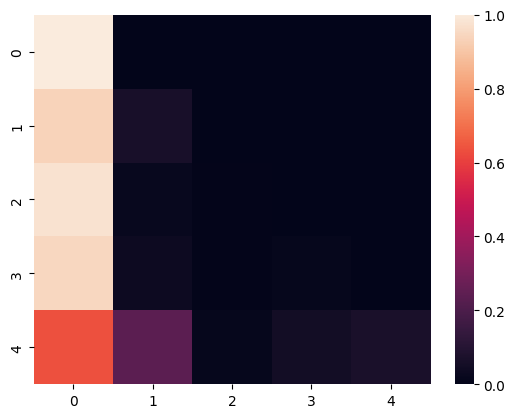

In [55]:
import seaborn as sns
# visualize the attention output of one head 
sns.heatmap(outputs.attentions[9][0, 0, :, :].cpu().numpy())


### 4.3 Logits → Token-Wahrscheinlichkeiten

Die **Logits** an der letzten Position bestimmen, was als nächstes vorhergesagt wird.

In [41]:
# Logits an der LETZTEN Position (= unmittelbar vor dem nächsten Token)
last_logits = outputs.logits[0, -1, :]  # Shape: (50257,)

# Softmax → Wahrscheinlichkeitsverteilung
probs = torch.softmax(last_logits, dim=-1)

# Top-5 wahrscheinlichste nächste Tokens
top_probs, top_ids = torch.topk(probs, k=5)

print(f"Prompt: {prompt!r}")
print(f"Top-5 nächste Tokens:\n")
for rank, (p, tid) in enumerate(zip(top_probs.tolist(), top_ids.tolist()), 1):
    token_str = tokenizer.decode([tid])
    print(f"  #{rank}: {token_str!r:15s} (ID {tid:5d}, P = {p:.4f})")

Prompt: 'The capital of France is'
Top-5 nächste Tokens:

  #1: ' the'          (ID   262, P = 0.0846)
  #2: ' now'          (ID   783, P = 0.0479)
  #3: ' a'            (ID   257, P = 0.0462)
  #4: ' France'       (ID  4881, P = 0.0324)
  #5: ' Paris'        (ID  6342, P = 0.0322)


**Hier passiert die Magie:**  
GPT-2 hat ohne Training, ohne Prompt Engineering — nur aus den Pretraining-Daten — gelernt, dass nach „The capital of France is" ein Leerzeichen + „Paris" das wahrscheinlichste nächste Token ist.  
Das ist **Faktenwissen** im Modell. Eine der Kern-Fragen der Interpretability lautet: **Wo ist dieses Wissen gespeichert?**

### 4.4 Logit Difference — Unsere zentrale Metrik

Statt absoluter Wahrscheinlichkeiten verwenden wir oft die **Logit Difference**:
$$ \text{LD} = \text{logit}(\text{korrekt}) - \text{logit}(\text{inkorrekt}) $$

**Warum?** Logit-Differenzen sind **linear** mit Aktivierungsänderungen — ideal für Patching-Experimente in Block 5.

In [42]:
# 'Paris' vs. 'London' nach 'The capital of France is'
paris_id  = tokenizer.encode(' Paris')[0]
london_id = tokenizer.encode(' London')[0]

logit_paris  = last_logits[paris_id].item()
logit_london = last_logits[london_id].item()
ld = logit_paris - logit_london

print(f"Logit(' Paris'):   {logit_paris:+.4f}")
print(f"Logit(' London'):  {logit_london:+.4f}")
print(f"Logit Difference:  {ld:+.4f}")
print()
print(f"-> LD > 0: Modell favorisiert das korrekte Token. {'✓ korrekt' if ld > 0 else '✗ unerwartet'}")

Logit(' Paris'):   -101.2143
Logit(' London'):  -103.9371
Logit Difference:  +2.7228

-> LD > 0: Modell favorisiert das korrekte Token. ✓ korrekt


---
## 5. Open-Weight vs. API vs. Lokales Serving

Wir haben gerade auf **alle internen Berechnungen** zugegriffen: Logits, Hidden States, Attention.  
Das ist nur möglich, weil GPT-2 ein **Open-Weight-Modell** ist.

### Vergleich der Zugangsmodi

| Aspekt | Open-Weight (GPT-2, LLaMA) | API (GPT-4, Claude) | Lokal (Ollama) |
|--------|-----------------|---------------------|----------------|
| Hidden States | ✓ | ✗ | ✗ (meist) |
| Attention | ✓ | ✗ | ✗ (meist) |
| Gewichte | ✓ (Datei) | ✗ | ✓ (Datei) |
| Gradienten | ✓ | ✗ | ✗ |
| Fine-Tuning | ✓ | begrenzt | (möglich) |
| Modellgröße | klein–mittel | groß | klein–mittel |
| Latenz | hoch (lokal) | niedrig (Cloud) | mittel |
| Datenschutz | ✓ (lokal) | ✗ (Cloud) | ✓ (lokal) |

### Konsequenz für Forschung

**Mechanistische Interpretability** erfordert Open-Weight-Zugang — wir müssen auf Tensorebene mit dem Modell arbeiten können.  
API-Modelle sind für **Anwendungen** stark, aber als **Forschungsobjekt** intransparent.

→ Für unser Semesterprojekt: GPT-2 als Open-Weight-Modell.

---
## 6. Zusammenfassung

Sie haben in dieser Demo gesehen:

1. **Hugging Face Hub** — Modelle, Datasets, Model Cards
2. **Pipeline API vs. Manueller Zugriff** — Pipeline ist bequem, Low-Level brauchen wir für Interpretability
3. **Tokenisierung im Detail:**
   - **BPE** — wie Text zu Token-IDs wird
   - **`encode` / `decode` / `tokenize`** und Hilfsmethoden
   - **Spezial-Tokens** (BOS, EOS, PAD, UNK) — und warum GPT-2 keinen PAD-Token hat
   - **Padding, Truncation, Batch-Encoding** mit `tokenizer(...)`
   - **attention_mask** als Komplement zum Padding
   - **Token-Grenzen** als Voraussetzung für saubere Interpretability-Analyse
4. **Forward Pass mit Hidden States und Attention** — die Grundlage für alle weiteren Analysen heute
5. **Logit Difference** — die Metrik, die uns durch Block 4 und Block 5 begleitet
6. **Open-Weight als Voraussetzung** für mechanistische Interpretability

**Als nächstes (10:00–10:30):**  
Sie übertragen diese Techniken in der **Übung** auf das Modell, das Sie für Ihr Gruppen-Phänomen verwenden.

In [ ]:
# Tokenisierung eines längeren Textes
ex_prompt = "The second world war ended in"
# ex_prompt = "The dog barked at the stranger but it didn't bite him"
inputs = tokenizer(ex_prompt, return_tensors='pt').to(device)

print(f"Input-IDs Shape:     {inputs['input_ids'].shape}")
print(f"Input-IDs:           {inputs['input_ids'].tolist()}")
print(f"Attention-Mask:      {inputs['attention_mask'].tolist()}")




Input-IDs Shape:     torch.Size([1, 13])
Input-IDs:           [[464, 3290, 21405, 276, 379, 262, 16195, 475, 340, 1422, 470, 13197, 683]]
Attention-Mask:      [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


In [93]:
# Modellausgabe mit Hidden States und Attentions

with torch.no_grad():  # Kein Gradient nötig → spart Speicher
    outputs = model(
        **inputs,
        output_hidden_states=True,
        output_attentions=True,
    )

print(f"Logits Shape:           {outputs.logits.shape}")
print(f"  -> (batch, seq_len, vocab_size) = (1, 5, 50257)")
print()
print(f"Hidden States: {len(outputs.hidden_states)} Tensoren")
print(f"  -> 1 (Embedding) + 12 (nach jeder Schicht)")
print(f"  -> Shape jedes Tensors: {outputs.hidden_states[0].shape}")
print()
print(f"Attentions: {len(outputs.attentions)} Tensoren")
print(f"  -> 12 (eine pro Schicht)")
print(f"  -> Shape jedes Tensors: {outputs.attentions[0].shape}")
print(f"  -> (batch, n_heads, seq_len, seq_len) = (1, 12, 5, 5)")

Logits Shape:           torch.Size([1, 13, 50257])
  -> (batch, seq_len, vocab_size) = (1, 5, 50257)

Hidden States: 13 Tensoren
  -> 1 (Embedding) + 12 (nach jeder Schicht)
  -> Shape jedes Tensors: torch.Size([1, 13, 768])

Attentions: 12 Tensoren
  -> 12 (eine pro Schicht)
  -> Shape jedes Tensors: torch.Size([1, 12, 13, 13])
  -> (batch, n_heads, seq_len, seq_len) = (1, 12, 5, 5)


In [94]:
# visualize the attention output of one head
# Logits an der LETZTEN Position (= unmittelbar vor dem nächsten Token)
last_logits = outputs.logits[0, -1, :]  # Shape: (50257,)

# Softmax → Wahrscheinlichkeitsverteilung
probs = torch.softmax(last_logits, dim=-1)

# Top-5 wahrscheinlichste nächste Tokens
top_probs, top_ids = torch.topk(probs, k=5)

print(f"Prompt: {prompt!r}")
print(f"Top-5 nächste Tokens:\n")
for rank, (p, tid) in enumerate(zip(top_probs.tolist(), top_ids.tolist()), 1):
    token_str = tokenizer.decode([tid])
    print(f"  #{rank}: {token_str!r:15s} (ID {tid:5d}, P = {p:.4f})")

Prompt: 'The capital of France is'
Top-5 nächste Tokens:

  #1: '.'             (ID    13, P = 0.5257)
  #2: ','             (ID    11, P = 0.1401)
  #3: ' and'          (ID   290, P = 0.0645)
  #4: ' or'           (ID   393, P = 0.0386)
  #5: ' as'           (ID   355, P = 0.0164)


<Axes: >

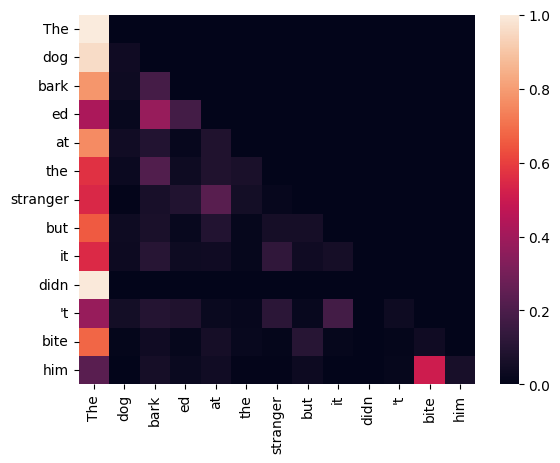

In [103]:
import seaborn as sns
# visualize the attention output of one head
# Get tokens from the current input
input_tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
# Clean up special GPT-2 characters (Ġ represents space)
input_tokens = [token.replace('Ġ', ' ').strip() for token in input_tokens]
sns.heatmap(outputs.attentions[11][0, 11, :, :].cpu().numpy(), 
            xticklabels=input_tokens, 
            yticklabels=input_tokens)

In [104]:
# 'Cats' vs. 'Coffee' relevant für den nächsten Satz: "the dog barked at the stranger but it didn't bite him"
true_id  = tokenizer.encode('1945')[0]
false_id = tokenizer.encode(' Coffee')[0]

logit_true  = last_logits[true_id].item()
logit_false = last_logits[false_id].item()
ld = logit_true - logit_false

print(f"Logit('1945'):   {logit_true:+.4f}")
print(f"Logit(' Coffee'):  {logit_false:+.4f}")
print(f"Logit Difference:  {ld:+.4f}")
print()
print(f"-> LD > 0: Modell favorisiert das korrekte Token. {'✓ korrekt' if ld > 0 else '✗ unerwartet'}")

Logit('1945'):   -105.1785
Logit(' Coffee'):  -102.8105
Logit Difference:  -2.3680

-> LD > 0: Modell favorisiert das korrekte Token. ✗ unerwartet
